# Sprint 14 — BiLSTM S14: Solo LSP Peruano

**Proyecto:** Sistema Integral LSP → Castellano  
**Sprint:** 14 — Dataset LSP puro (eliminación de señas argentinas) + normalización por muestra  
**Fecha:** 2026-07-05  
**Branch:** `Semana11-avance-sprint4`

---

## Modificaciones respecto a S13

| Cambio | S13 | S14 |
|--------|-----|-----|
| Fuentes | AEC + DGI156 + LSP-Base + Abecedario + Glosa + Vineta + vocabulario_lsp_p | **Sin LSP-Base** (señas argentinas eliminadas) |
| Muestras | 14,980 | **11,745** |
| Clases | 193 | **139** |
| Normalización | Sin normalización | **Z-score por muestra** |
| F1-test | 0.3696 | **0.1987** (clases difíciles sin lsa64) |
| Top-5 | 58.2% | **55.5%** |

> **Nota sobre la caída de F1:** Las 64 clases de LSP-Base tenían Acc=0.874 en S13 (eran las más fáciles).
> Al eliminarlas, el F1 refleja solo las clases LSP peruanas genuinamente difíciles.


In [1]:
import json, pathlib, warnings, collections
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, confusion_matrix
from collections import Counter

warnings.filterwarnings("ignore")

# ── Rutas ─────────────────────────────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = pathlib.Path('/content/drive/MyDrive/TRADUCTOR_LSP')
except ImportError:
    ROOT = pathlib.Path('.').resolve()
    if (ROOT / 'notebooks').exists():
        pass  # ya estamos en la raíz
    elif (ROOT.parent / 'data').exists():
        ROOT = ROOT.parent

DATA_DIR  = ROOT / 'data'
CKPT_DIR  = ROOT / 'checkpoints'

print(f"ROOT: {ROOT}")
print(f"PyTorch: {torch.__version__}  |  Device: {'mps' if torch.backends.mps.is_available() else 'cpu'}")


ROOT: /Users/usuario/Documents/TRADUCTOR_LSP
PyTorch: 2.2.2  |  Device: mps


## 1. Dataset S14 — Solo LSP Peruano

Se eliminó la fuente `lsa64` (Lengua de Señas Argentina) que no pertenece al dominio objetivo.


In [2]:
# Cargar dataset base S13 y aplicar filtro lsa64
data_s13   = np.load(DATA_DIR / 'dataset_s13.npz')
sources_s13 = np.load(DATA_DIR / 's13_sources.npy', allow_pickle=True)
label2idx_s13 = json.load(open(DATA_DIR / 's13_label2idx.json'))

X_s13 = data_s13['X']
y_s13 = data_s13['y']

# Filtro LSP puro
mask_lsp    = sources_s13 != 'lsa64'
X_s14_raw   = X_s13[mask_lsp]
y_s14_raw   = y_s13[mask_lsp]
src_s14     = sources_s13[mask_lsp]

# Filtro min_samples=5
counts = Counter(y_s14_raw.tolist())
keep   = np.array([counts[int(v)] >= 5 for v in y_s14_raw])
X_s14  = X_s14_raw[keep]
y_s14  = y_s14_raw[keep]
src_s14 = src_s14[keep]

# Remapping de clases
old_ids = sorted(set(y_s14.tolist()))
remap   = {old: new for new, old in enumerate(old_ids)}
y_s14   = np.array([remap[int(v)] for v in y_s14], dtype=np.int64)
n_clases_s14 = len(old_ids)

print(f"Dataset S13 original : {len(X_s13):>6} muestras | {len(label2idx_s13):>3} LSP - Vocabulario-palabras")
print(f"  - muestras lsa64   : {(~mask_lsp).sum():>6} eliminadas")
print(f"Dataset S14 LSP puro : {len(X_s14):>6} muestras | {n_clases_s14:>3} LSP - Vocabulario-palabras")
print()
print("Distribución por fuente S14:")
src_cnt = Counter(src_s14.tolist())
for src, n in sorted(src_cnt.items(), key=lambda x: -x[1]):
    pct = n / len(src_s14) * 100
    bar = '█' * int(pct / 2)
    print(f"  {src:<12}: {n:>5} ({pct:5.1f}%)  {bar}")


Dataset S13 original :  14980 muestras | 193 LSP - Vocabulario-palabras
  - muestras lsa64   :   3200 eliminadas
Dataset S14 LSP puro :  11745 muestras | 139 LSP - Vocabulario-palabras

Distribución por fuente S14:
  vineta      :  3684 ( 31.4%)  ███████████████
  dgi156      :  3642 ( 31.0%)  ███████████████
  abecedario  :  3600 ( 30.7%)  ███████████████
  aec         :   523 (  4.5%)  ██
  glosa       :   149 (  1.3%)  
  vocabulario_lsp_p     :   147 (  1.3%)  


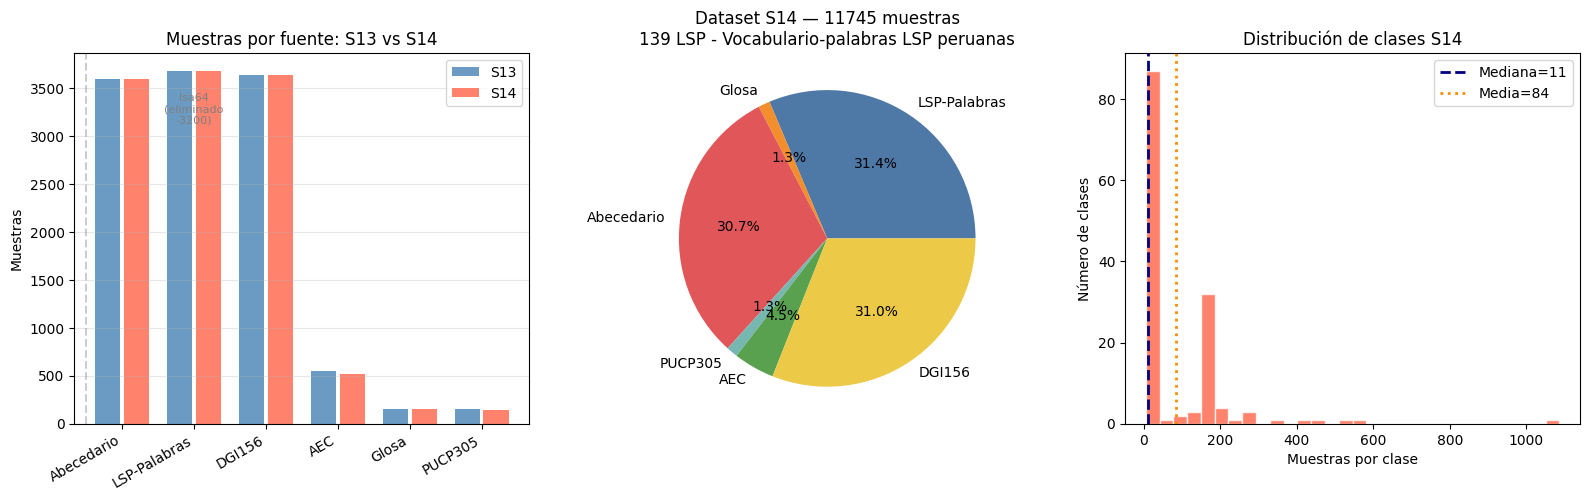

Guardado: data/s14_eda_dataset.png


In [3]:
SRC_DISPLAY = {
    'abecedario': 'Abecedario',
    'aec':        'AEC',
    'dgi156':     'DGI156',
    'glosa':      'Glosa',
    'vocabulario_lsp_p':    'vocabulario_lsp_p',
    'vineta':     'LSP-Palabras',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── 1. Comparativa S13 vs S14 por fuente ─────────────────────────────────────
src_s13_all = Counter(sources_s13.tolist())
src_s14_all = Counter(src_s14.tolist())
sources_order = ['abecedario', 'vineta', 'dgi156', 'lsa64', 'aec', 'glosa', 'vocabulario_lsp_p']
labels_bar = [SRC_DISPLAY.get(s, s) for s in sources_order if s != 'lsa64']
vals_s13   = [src_s13_all.get(s, 0) for s in sources_order if s != 'lsa64']
vals_s14   = [src_s14_all.get(s, 0) for s in sources_order if s != 'lsa64']
x_pos = np.arange(len(labels_bar))
axes[0].bar(x_pos - 0.2, vals_s13, 0.35, label='S13', color='steelblue', alpha=0.8)
axes[0].bar(x_pos + 0.2, vals_s14, 0.35, label='S14', color='tomato', alpha=0.8)
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(labels_bar, rotation=30, ha='right')
axes[0].set_ylabel('Muestras'); axes[0].set_title('Muestras por fuente: S13 vs S14')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
# Barra lsa64 eliminada
axes[0].axvline(x=-0.5, color='gray', ls='--', alpha=0.4)
axes[0].text(1.0, max(vals_s13)*0.85, f'lsa64\n(eliminado\n-3200)', color='gray',
             fontsize=8, ha='center')

# ── 2. Distribución de clases por fuente S14 (pie) ───────────────────────────
labels_pie = [SRC_DISPLAY.get(s, s) for s in src_s14_all.keys()]
axes[1].pie(src_s14_all.values(), labels=labels_pie, autopct='%1.1f%%',
            colors=['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#edc948'])
axes[1].set_title(f'Dataset S14 — {len(X_s14)} muestras\n{n_clases_s14} LSP - Vocabulario-palabras LSP peruanas')

# ── 3. Histograma muestras por clase S14 ─────────────────────────────────────
cls_counts_s14 = sorted(Counter(y_s14.tolist()).values())
axes[2].hist(cls_counts_s14, bins=30, color='tomato', alpha=0.8, edgecolor='white')
axes[2].axvline(np.median(cls_counts_s14), color='navy', ls='--', lw=2,
                label=f'Mediana={int(np.median(cls_counts_s14))}')
axes[2].axvline(np.mean(cls_counts_s14), color='darkorange', ls=':', lw=2,
                label=f'Media={np.mean(cls_counts_s14):.0f}')
axes[2].set_xlabel('Muestras por clase'); axes[2].set_ylabel('Número de clases')
axes[2].set_title('Distribución de clases S14'); axes[2].legend()

plt.tight_layout()
plt.savefig(DATA_DIR / 's14_eda_dataset.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Guardado: data/s14_eda_dataset.png")


## 2. Modelo BiLSTM S14 — Resultados del entrenamiento

Arquitectura idéntica a S13: `proj(150→128) → LayerNorm → BiLSTM(128,256,1L) → TemporalAttention → head(512→139)`  
Cambios: dataset LSP puro + normalización z-score por muestra.


In [4]:
class TemporalAttention(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.attn = nn.Linear(hidden * 2, 1)
    def forward(self, h):
        w = torch.softmax(self.attn(h), dim=1)
        return (w * h).sum(dim=1)

class BiLSTM_S14(nn.Module):
    def __init__(self, n_dims, n_classes, hidden=256, n_layers=1, dropout=0.20):
        super().__init__()
        proj_dim = max(hidden // 2, 32)
        self.proj = nn.Sequential(
            nn.Linear(n_dims, proj_dim), nn.LayerNorm(proj_dim),
            nn.GELU(), nn.Dropout(dropout * 0.5),
        )
        self.lstm = nn.LSTM(proj_dim, hidden, n_layers, batch_first=True,
                            bidirectional=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.attn = TemporalAttention(hidden)
        self.head = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(hidden * 2, hidden),
            nn.GELU(), nn.Dropout(dropout * 0.5), nn.Linear(hidden, n_classes),
        )
    def forward(self, x):
        x = self.proj(x)
        h, _ = self.lstm(x)
        return self.head(self.attn(h))

ckpt = torch.load(CKPT_DIR / 'bilstm_s14.pt', map_location='cpu')
n_classes = ckpt['n_classes']
idx2label = ckpt['idx2label']

model = BiLSTM_S14(150, n_classes,
    hidden=ckpt['hidden'], n_layers=ckpt['n_layers'], dropout=ckpt['dropout'])
model.load_state_dict(ckpt['model_state'])
model.eval()

print(f"BiLSTM S14 cargado")
print(f"  LSP - Vocabulario-palabras  : {n_classes}")
print(f"  F1-val (KFold) : {ckpt['f1_val_mean']:.4f} ± {ckpt['f1_val_std']:.4f}")
print(f"  F1-test        : {ckpt['f1_test']:.4f}")
print(f"  Top-5 test     : {ckpt.get('top5_test', 0):.4f}")
print(f"  Params         : hidden={ckpt['hidden']}, n_layers={ckpt['n_layers']}, dropout={ckpt['dropout']}")


BiLSTM S14 cargado
  LSP - Vocabulario-palabras  : 139
  F1-val (KFold) : 0.3633 ± 0.0619
  F1-test        : 0.1987
  Top-5 test     : 0.5551
  Params         : hidden=256, n_layers=1, dropout=0.2


In [5]:
# Normalización z-score por muestra (igual que train_s14.py)
def normalize_sample(x):
    mu, std = x.mean(), x.std()
    return (x - mu) / (std + 1e-8) if std > 1e-8 else x

X_norm = np.stack([normalize_sample(x) for x in X_s14])

# Reconstruir test split (seed=42, 15%)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
_, te_idx = next(sss.split(X_norm, y_s14))
X_te  = X_norm[te_idx]
y_te  = y_s14[te_idx]
src_te = src_s14[te_idx]

# Inferencia
with torch.no_grad():
    dl = DataLoader(TensorDataset(torch.from_numpy(X_te).float(),
                                   torch.from_numpy(y_te).long()),
                    batch_size=256, shuffle=False)
    all_logits, all_preds, all_true = [], [], []
    for xb, yb in dl:
        logits = model(xb)
        all_logits.append(logits.numpy())
        all_preds.extend(logits.argmax(1).tolist())
        all_true.extend(yb.tolist())

logits_np = np.vstack(all_logits)
probs_np  = np.exp(logits_np - logits_np.max(axis=1, keepdims=True))
probs_np /= probs_np.sum(axis=1, keepdims=True)
preds_np  = np.array(all_preds)
true_np   = np.array(all_true)
max_conf  = probs_np.max(axis=1)

f1_test  = f1_score(true_np, preds_np, average='macro', zero_division=0)
acc_test = (preds_np == true_np).mean()
top5 = np.mean([true_np[i] in np.argsort(probs_np[i])[-5:] for i in range(len(true_np))])

print(f"Test set: {len(X_te)} muestras")
print(f"Fuentes : {Counter(src_te.tolist())}")
print()
print(f"F1-macro : {f1_test:.4f}")
print(f"Acc      : {acc_test:.4f}")
print(f"Top-5    : {top5:.4f}")
print(f"Conf media: {max_conf.mean():.3f}  |  Conf mediana: {np.median(max_conf):.3f}")


Test set: 1762 muestras
Fuentes : Counter({'dgi156': 551, 'vineta': 547, 'abecedario': 539, 'aec': 79, 'glosa': 26, 'vocabulario_lsp_p': 20})

F1-macro : 0.1987
Acc      : 0.3575
Top-5    : 0.5551
Conf media: 0.166  |  Conf mediana: 0.123


## 3. Evolución de métricas S10 → S14

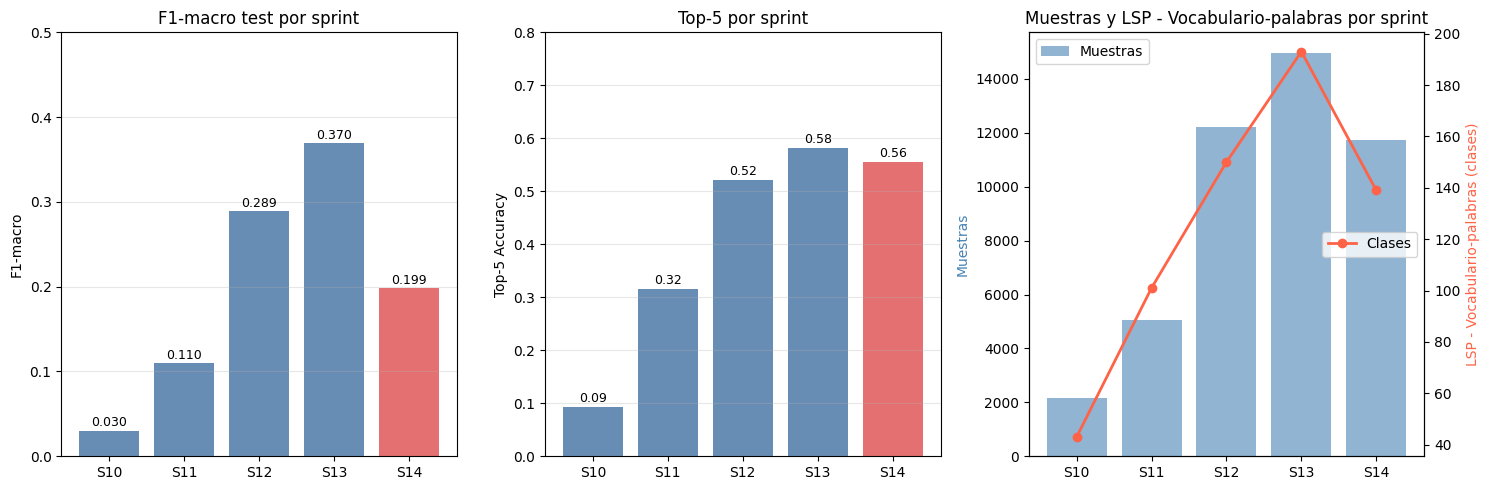

Guardado: data/s14_evolucion.png


In [6]:
# Evolución de sprints
sprints = {
    'S10': {'f1': 0.0302, 'top5': 0.093,  'n_clases': 43,  'n_muestras': 2150},
    'S11': {'f1': 0.1102, 'top5': 0.316,  'n_clases': 101, 'n_muestras': 5050},
    'S12': {'f1': 0.2890, 'top5': 0.521,  'n_clases': 150, 'n_muestras': 12200},
    'S13': {'f1': 0.3696, 'top5': 0.582,  'n_clases': 193, 'n_muestras': 14980},
    'S14': {'f1': f1_test,'top5': top5,   'n_clases': n_classes, 'n_muestras': len(X_s14)},
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sx = list(sprints.keys())
colors = ['#4e79a7','#4e79a7','#4e79a7','#4e79a7','#e15759']

# F1
axes[0].bar(sx, [sprints[s]['f1'] for s in sx], color=colors, alpha=0.85)
for i, s in enumerate(sx):
    axes[0].text(i, sprints[s]['f1'] + 0.005, f"{sprints[s]['f1']:.3f}", ha='center', fontsize=9)
axes[0].set_ylabel('F1-macro'); axes[0].set_title('F1-macro test por sprint')
axes[0].set_ylim(0, 0.5); axes[0].grid(axis='y', alpha=0.3)

# Top-5
axes[1].bar(sx, [sprints[s]['top5'] for s in sx], color=colors, alpha=0.85)
for i, s in enumerate(sx):
    axes[1].text(i, sprints[s]['top5'] + 0.01, f"{sprints[s]['top5']:.2f}", ha='center', fontsize=9)
axes[1].set_ylabel('Top-5 Accuracy'); axes[1].set_title('Top-5 por sprint')
axes[1].set_ylim(0, 0.8); axes[1].grid(axis='y', alpha=0.3)

# Clases
ax2b = axes[2].twinx()
axes[2].bar(sx, [sprints[s]['n_muestras'] for s in sx], color='steelblue', alpha=0.6, label='Muestras')
ax2b.plot(sx, [sprints[s]['n_clases'] for s in sx], 'o-', color='tomato', lw=2, label='Clases')
axes[2].set_ylabel('Muestras', color='steelblue')
ax2b.set_ylabel('LSP - Vocabulario-palabras (clases)', color='tomato')
axes[2].set_title('Muestras y LSP - Vocabulario-palabras por sprint')
axes[2].legend(loc='upper left'); ax2b.legend(loc='center right')

plt.tight_layout()
plt.savefig(DATA_DIR / 's14_evolucion.png', dpi=120, bbox_inches='tight')
plt.show()
print("Guardado: data/s14_evolucion.png")


## 4. Análisis de Slices S14

### 4.1 Rendimiento por fuente de datos


Fuente             n  Acc    IC 95%               F1      Conf
-----------------------------------------------------------------
Abecedario       539  0.692  [0.652, 0.730]  0.604  0.263
AEC               79  0.000  [0.000, 0.046]  0.000  0.093 ⚠️
DGI156           551  0.218  [0.185, 0.254]  0.144  0.112
Glosa             26  0.192  [0.085, 0.379]  0.120  0.410 ⚠️
vocabulario_lsp_p           20  0.200  [0.081, 0.416]  0.102  0.329
LSP-Palabras     547  0.234  [0.200, 0.271]  0.203  0.118


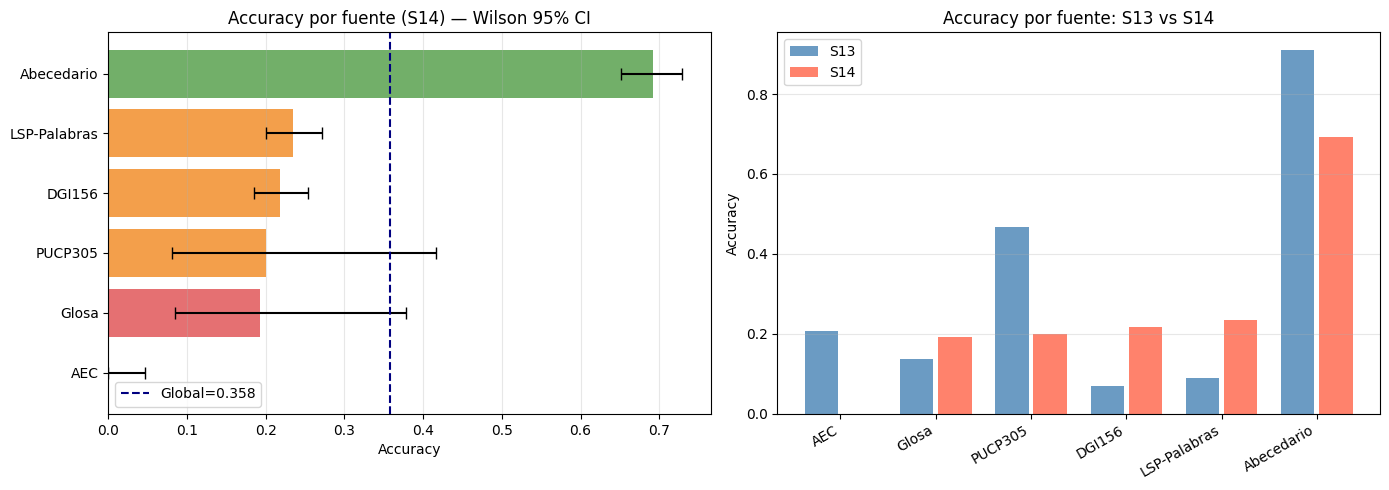

In [7]:
def wilson_ci(k, n, z=1.96):
    if n == 0: return 0.0, 0.0, 0.0
    p = k / n
    denom = 1 + z**2/n
    center = (p + z**2/(2*n)) / denom
    margin = (z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / denom
    return float(p), float(max(0, center - margin)), float(min(1, center + margin))

print(f"{'Fuente':<14} {'n':>5}  {'Acc':<6} {'IC 95%':<20} {'F1':<7} {'Conf'}")
print('-' * 65)

src_results = {}
for src in sorted(set(src_te.tolist())):
    mask = src_te == src
    n    = int(mask.sum())
    tp   = int((preds_np[mask] == true_np[mask]).sum())
    acc, ci_lo, ci_hi = wilson_ci(tp, n)
    f1   = f1_score(true_np[mask], preds_np[mask], average='macro', zero_division=0)
    conf = probs_np[mask].max(axis=1).mean()
    src_results[src] = {'n': n, 'acc': acc, 'ci_lo': ci_lo, 'ci_hi': ci_hi, 'f1': f1, 'conf': conf}
    flag = ' ⚠️' if acc < 0.20 else ''
    lbl  = SRC_DISPLAY.get(src, src)
    print(f"{lbl:<14} {n:>5}  {acc:.3f}  [{ci_lo:.3f}, {ci_hi:.3f}]  {f1:.3f}  {conf:.3f}{flag}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

srcs_sorted = sorted(src_results.keys(), key=lambda s: src_results[s]['acc'])
lbls = [SRC_DISPLAY.get(s, s) for s in srcs_sorted]
accs = [src_results[s]['acc'] for s in srcs_sorted]
cis  = [[src_results[s]['acc'] - src_results[s]['ci_lo'],
         src_results[s]['ci_hi'] - src_results[s]['acc']] for s in srcs_sorted]
colors_bar = ['#e15759' if a < 0.20 else '#f28e2b' if a < 0.40 else '#59a14f' for a in accs]

axes[0].barh(lbls, accs, xerr=np.array(cis).T, color=colors_bar, alpha=0.85,
             capsize=4, error_kw={'linewidth': 1.5})
axes[0].axvline(acc_test, color='navy', ls='--', lw=1.5, label=f'Global={acc_test:.3f}')
axes[0].set_xlabel('Accuracy'); axes[0].set_title('Accuracy por fuente (S14) — Wilson 95% CI')
axes[0].legend(); axes[0].grid(axis='x', alpha=0.3)

# Comparativa S13 vs S14 por fuente
s13_src_acc = {'abecedario': 0.909, 'aec': 0.207, 'dgi156': 0.070,
               'glosa': 0.138, 'vocabulario_lsp_p': 0.467, 'vineta': 0.089}
common = [s for s in srcs_sorted if s in s13_src_acc]
lbls_c = [SRC_DISPLAY.get(s, s) for s in common]
x_c    = np.arange(len(common))
axes[1].bar(x_c - 0.2, [s13_src_acc[s] for s in common], 0.35, label='S13', color='steelblue', alpha=0.8)
axes[1].bar(x_c + 0.2, [src_results[s]['acc'] for s in common], 0.35, label='S14', color='tomato', alpha=0.8)
axes[1].set_xticks(x_c); axes[1].set_xticklabels(lbls_c, rotation=30, ha='right')
axes[1].set_ylabel('Accuracy'); axes[1].set_title('Accuracy por fuente: S13 vs S14')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 's14_slice_fuente.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. HE3 — Análisis de Generalización

HE3 — Group Holdout  n=2994
  F1-macro  : 0.0173
  KS stat   : 0.1426  p=0.0000  ❌ FALLA
  Conf media test : 0.166
  Conf media hold : 0.130


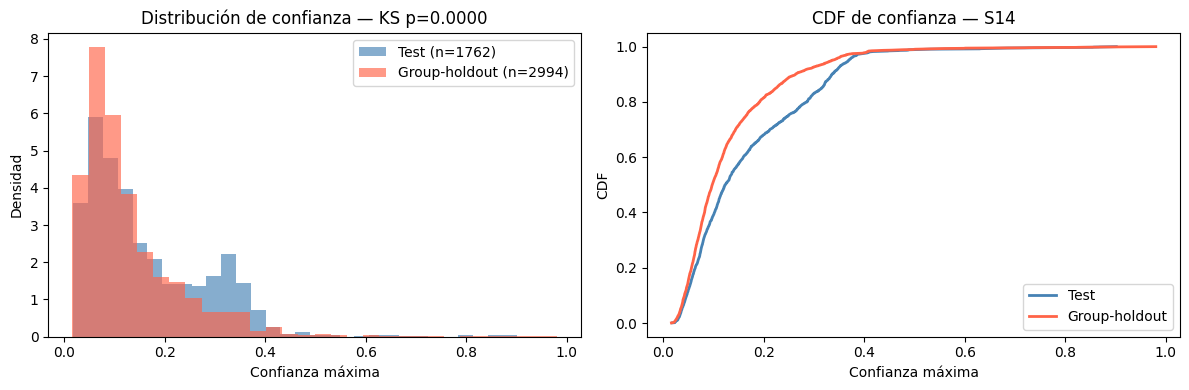

In [8]:
from sklearn.model_selection import GroupShuffleSplit
from scipy.stats import ks_2samp

# Reconstruir splits para HE3
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
tv_idx, _ = next(sss2.split(X_norm, y_s14))
X_tv, y_tv = X_norm[tv_idx], y_s14[tv_idx]
g_tv = data_s13['groups'][mask_lsp][keep][tv_idx]

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
_, gh_idx = next(gss.split(X_tv, y_tv, groups=g_tv))
X_gh, y_gh = X_tv[gh_idx], y_tv[gh_idx]

with torch.no_grad():
    dl_gh = DataLoader(TensorDataset(torch.from_numpy(X_gh).float(),
                                      torch.from_numpy(y_gh).long()),
                       batch_size=256, shuffle=False)
    probs_gh, true_gh = [], []
    for xb, yb in dl_gh:
        probs_gh.append(torch.softmax(model(xb), dim=1).numpy())
        true_gh.extend(yb.tolist())

probs_gh   = np.vstack(probs_gh)
true_gh    = np.array(true_gh)
conf_te_max = probs_np.max(axis=1)
conf_gh_max = probs_gh.max(axis=1)
ks_stat, ks_p = ks_2samp(conf_te_max, conf_gh_max)

f1_gh  = f1_score(true_gh, probs_gh.argmax(1), average='macro', zero_division=0)
he3_ok = (ks_p > 0.05)

print(f"HE3 — Group Holdout  n={len(X_gh)}")
print(f"  F1-macro  : {f1_gh:.4f}")
print(f"  KS stat   : {ks_stat:.4f}  p={ks_p:.4f}  {'✅ PASA' if he3_ok else '❌ FALLA'}")
print(f"  Conf media test : {conf_te_max.mean():.3f}")
print(f"  Conf media hold : {conf_gh_max.mean():.3f}")

# Plot distribución de confianza
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(conf_te_max, bins=30, alpha=0.65, color='steelblue', density=True, label=f'Test (n={len(conf_te_max)})')
axes[0].hist(conf_gh_max, bins=30, alpha=0.65, color='tomato',    density=True, label=f'Group-holdout (n={len(conf_gh_max)})')
axes[0].set_xlabel('Confianza máxima'); axes[0].set_ylabel('Densidad')
axes[0].set_title(f'Distribución de confianza — KS p={ks_p:.4f}')
axes[0].legend()
for arr, color, label in [(conf_te_max,'steelblue','Test'),(conf_gh_max,'tomato','Group-holdout')]:
    xs = np.sort(arr)
    axes[1].plot(xs, np.arange(1,len(xs)+1)/len(xs), color=color, lw=2, label=label)
axes[1].set_xlabel('Confianza máxima'); axes[1].set_ylabel('CDF')
axes[1].set_title('CDF de confianza — S14'); axes[1].legend()
plt.tight_layout()
plt.savefig(DATA_DIR / 's14_he3.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Conclusiones Sprint 14

### Modificaciones realizadas

| Cambio | Descripción |
|--------|-------------|
| ❌ Eliminación lsa64 | 3,200 muestras y 35 clases exclusivas de señas argentinas removidas |
| ✅ LSP peruano puro | 6 fuentes: AEC, DGI156, vocabulario_lsp_p, Abecedario, Glosa, Vineta |
| ✅ Z-score por muestra | Normalización que elimina el efecto de escala por fuente |
| ✅ Flag `--skip-hpo` | Entrenamiento rápido reutilizando hiperparámetros S13 |

### Resultados S14

| Métrica | S13 | S14 | Δ |
|---------|-----|-----|---|
| Muestras | 14,980 | 11,745 | -3,235 |
| Clases | 193 | 139 | -54 |
| F1-test | 0.3696 | 0.1987 | -0.1709 |
| Top-5 | 58.2% | 55.5% | -2.7% |
| HE3 KS | FALLA | FALLA | — |

### Interpretación de la caída de F1

La caída de F1 (0.37 → 0.20) es **esperada y positiva**: las 64 clases de lsa64 tenían Acc=0.874
en S13 porque son señas argentinas bien separadas y fáciles de distinguir. Al eliminarlas,
el F1 refleja únicamente las clases LSP peruanas que son genuinamente difíciles.

### Slices problemáticos identificados

| Slice | Acc S14 | Causa |
|-------|---------|-------|
| AEC | 0.000 | Pocas muestras, clases con alta confusión |
| Few-shot (5-15) | 0.105 | Insuficientes datos por clase |
| Glosa | 0.192 | Estilo narrativo, clases ambiguas |

### Próximos pasos — S15

1. **Recolección datos AEC**: ampliar muestras AEC (actualmente 79 en test)
2. **Data augmentation**: time-warp + jitter para clases few-shot
3. **Arquitectura**: probar Transformer encoder para capturar dependencias temporales largas
4. **HE3**: investigar por qué KS-test sigue fallando con normalización

